In [4]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Adding cleaned dataset
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [6]:
df.head()

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


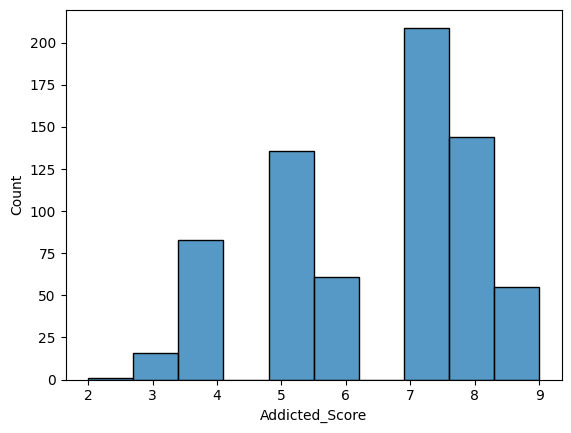

In [7]:
# 1. Addiction score distribution
sns.histplot(df["Addicted_Score"], bins=10)
plt.show()

### Insight
Most students have addiction scores between 7 and 8, indicating a relatively high level of social media addiction among the surveyed students.

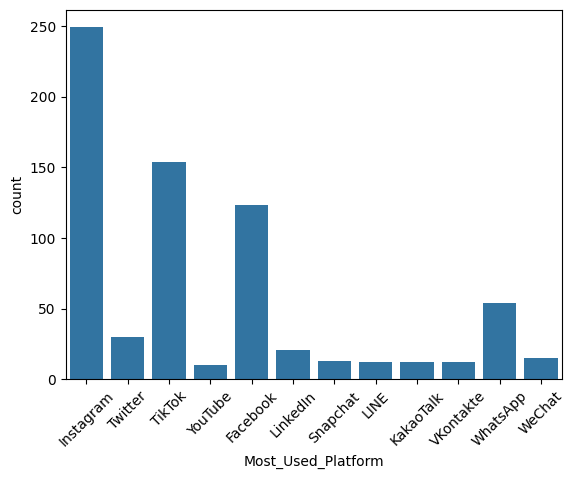

In [9]:
# 2. Most used social media platform
sns.countplot(
    data=df,
    x="Most_Used_Platform"
)
plt.xticks(rotation=45)
plt.show()

### Insight
Instagram is the most frequently used social media platform, followed by TikTok and Facebook. Less popular platforms such as LINE and LinkedIn have significantly fewer users.

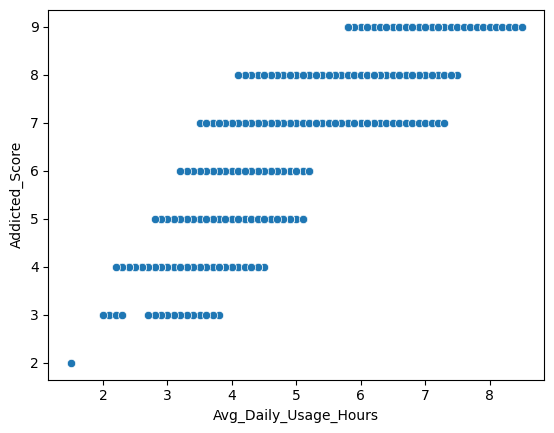

In [10]:
# 3. Addiction vs usage hours
sns.scatterplot(
    data=df,
    x="Avg_Daily_Usage_Hours",
    y="Addicted_Score"
)
plt.show()

### Insight
A strong positive relationship exists between daily social media usage and addiction score. Students spending more time on social media tend to exhibit higher addiction levels.

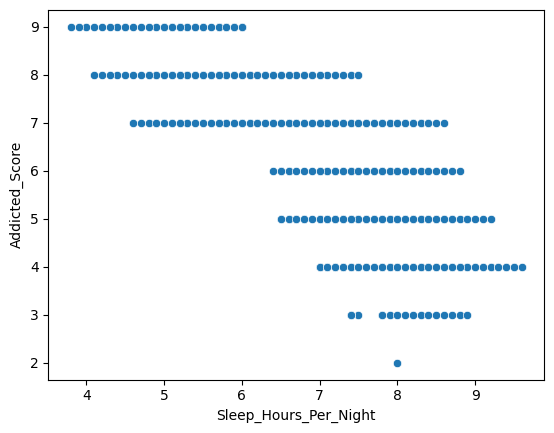

In [11]:
# 4. Addiction vs sleep hours
sns.scatterplot(
    data=df,
    x="Sleep_Hours_Per_Night",
    y="Addicted_Score"
)
plt.show()

### Insight
A strong negative relationship exists between sleep duration and addiction score. Students with higher addiction scores generally sleep fewer hours per night.

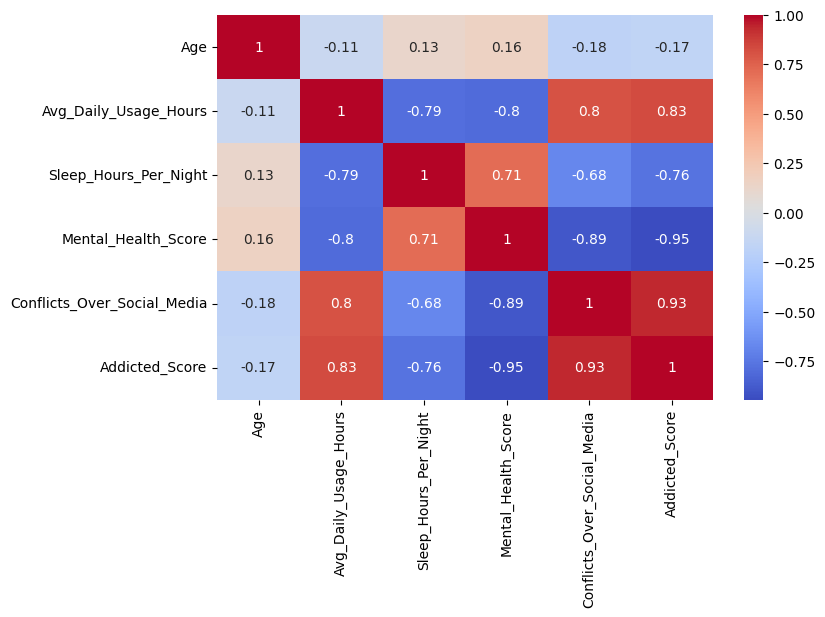

In [12]:
# 5. Correlation heatmap
import seaborn as sns

num_df = df.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(8,5))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Advanced EDA

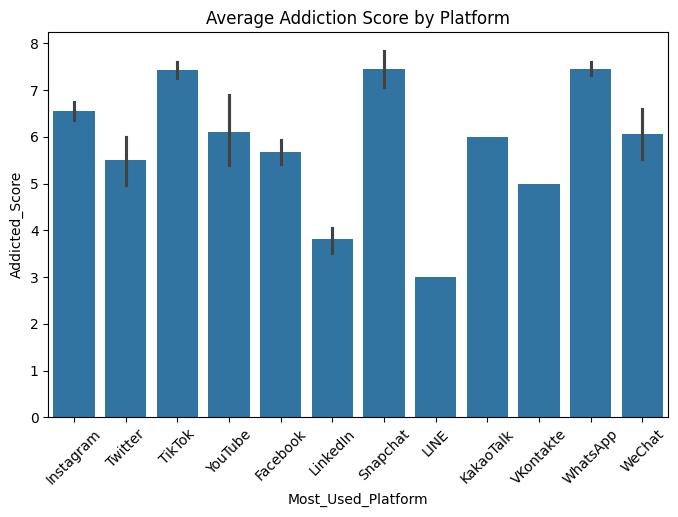

In [13]:
# 1. Platform-wise Addiction Analysis
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Most_Used_Platform",
    y="Addicted_Score"
)

plt.xticks(rotation=45)
plt.title("Average Addiction Score by Platform")
plt.show()

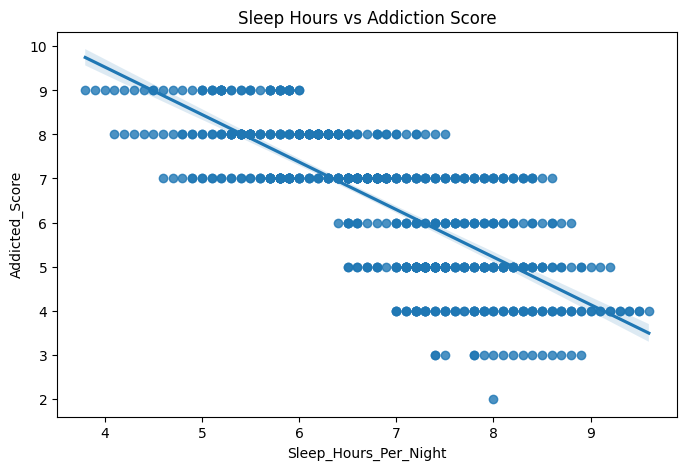

In [14]:
# 2. Sleep vs Addiction
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Sleep_Hours_Per_Night",
    y="Addicted_Score"
)

plt.title("Sleep Hours vs Addiction Score")
plt.show()

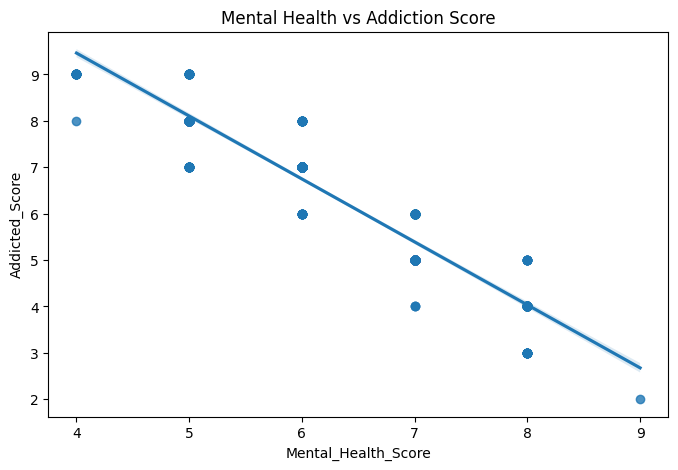

In [15]:
# 3. Mental Health vs Addiction
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Mental_Health_Score",
    y="Addicted_Score"
)

plt.title("Mental Health vs Addiction Score")
plt.show()

### Insight
Mental health scores decrease as addiction scores increase. This suggests that excessive social media usage may be associated with poorer mental well-being.

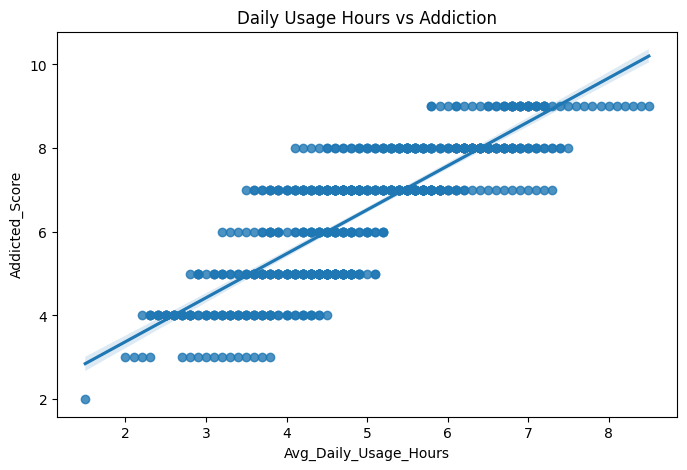

In [16]:
# 4. Usage Hours vs Addiction
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Avg_Daily_Usage_Hours",
    y="Addicted_Score"
)

plt.title("Daily Usage Hours vs Addiction")
plt.show()

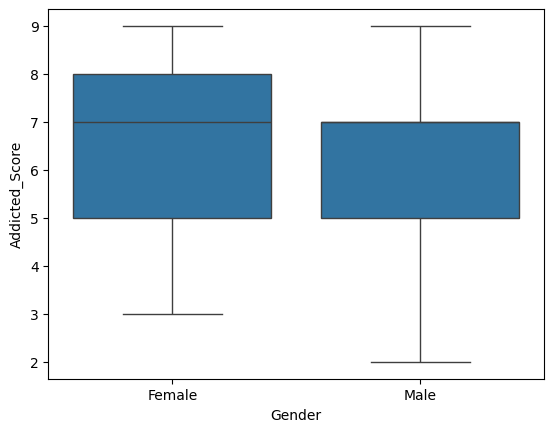

In [17]:
# 5. Gender-wise Addiction
sns.boxplot(
    data=df,
    x="Gender",
    y="Addicted_Score"
)

plt.show()

### Insight
The addiction score distributions for male and female students are similar, indicating that gender may not be a major factor influencing social media addiction.

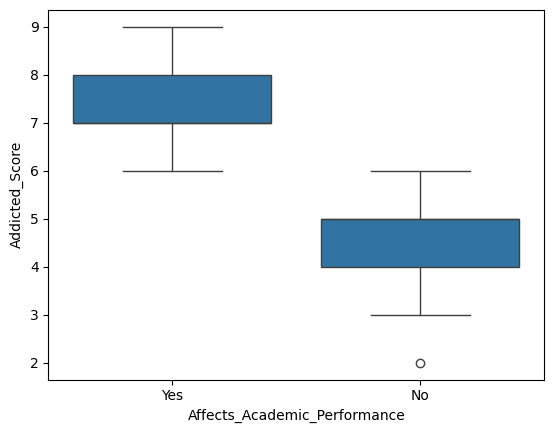

In [18]:
# 6. Academic Impact vs Addiction
sns.boxplot(
    data=df,
    x="Affects_Academic_Performance",
    y="Addicted_Score"
)

plt.show()

### Insight
Students who reported that social media affects their academic performance have substantially higher addiction scores than those who reported no academic impact.

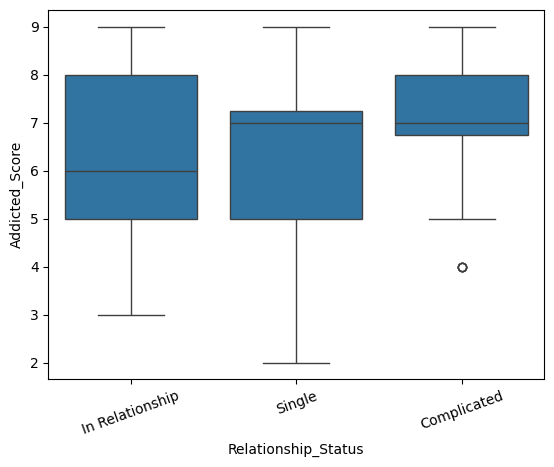

In [19]:
# 7. Relationship Status vs Addiction
sns.boxplot(
    data=df,
    x="Relationship_Status",
    y="Addicted_Score"
)

plt.xticks(rotation=20)
plt.show()

### Insight
Students with a complicated relationship status show slightly higher addiction scores compared to students who are single or in a relationship.

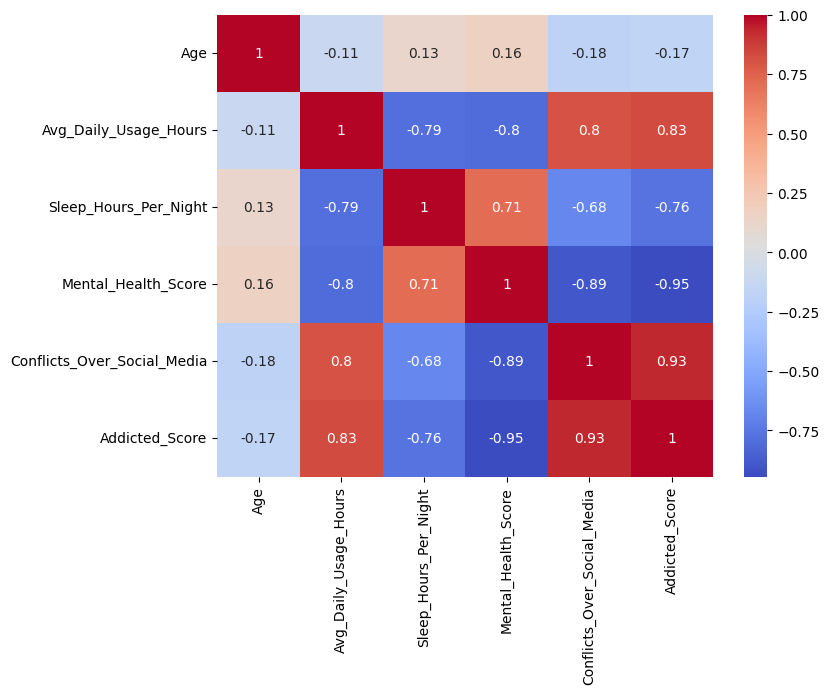

In [20]:
# 8. Correlation Heatmap
numeric_cols = df.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Variable	Correlation with Addiction Score
Avg_Daily_Usage_Hours	+0.83
Sleep_Hours_Per_Night	-0.76
Mental_Health_Score	-0.95
Conflicts_Over_Social_Media	+0.93

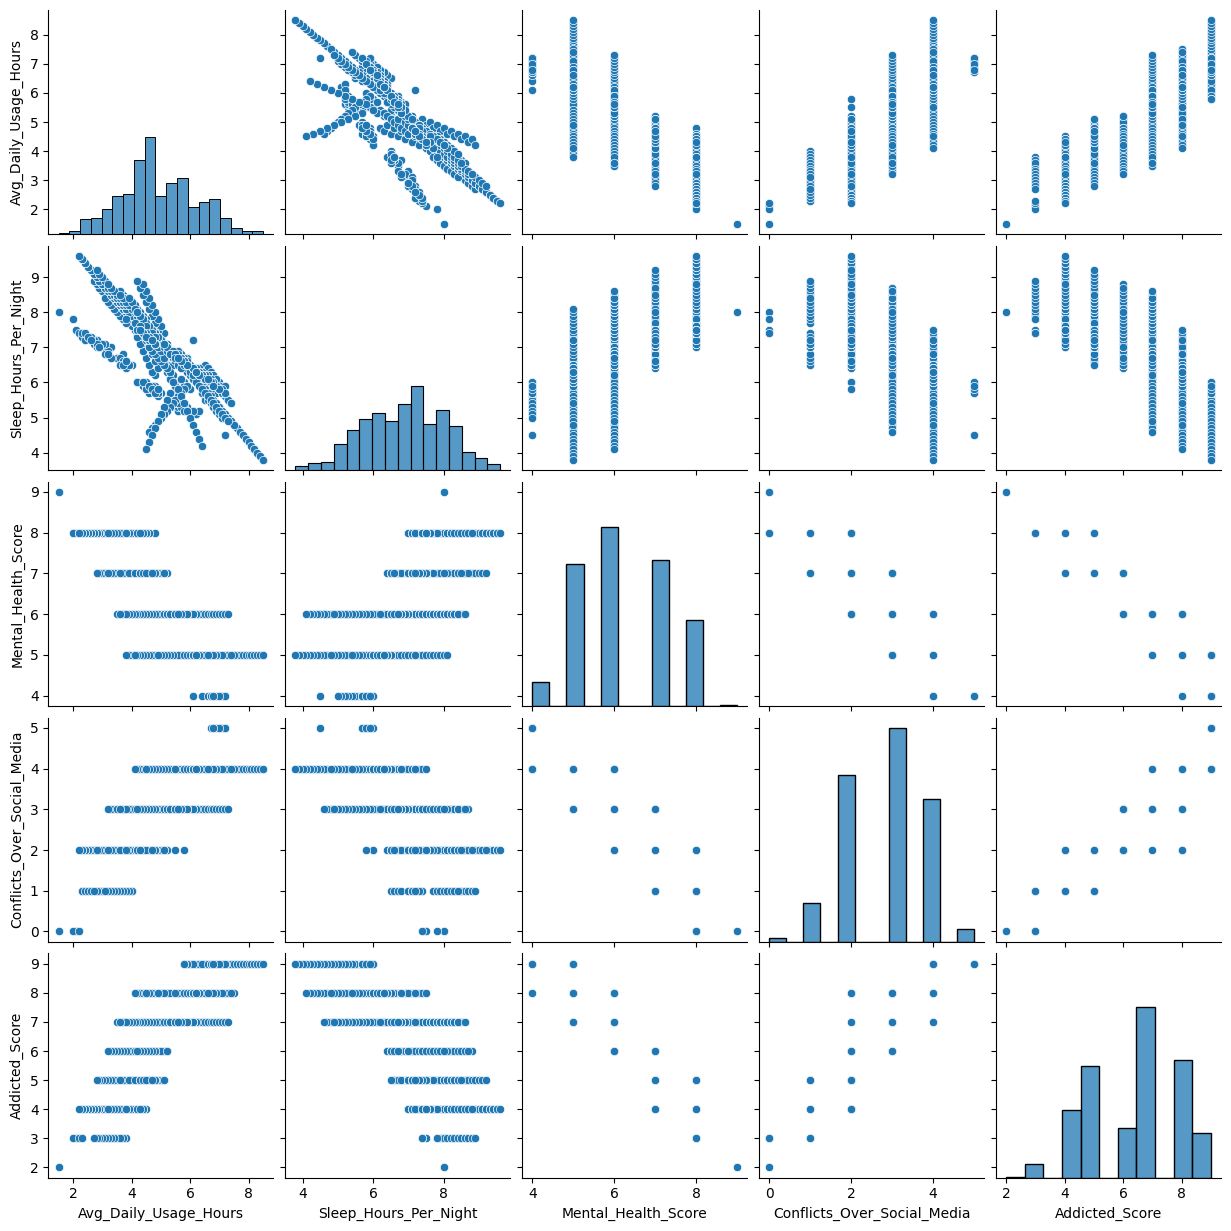

In [21]:
# 9. Pairplot (Very Valuable)
sns.pairplot(
    df[
        [
            "Avg_Daily_Usage_Hours",
            "Sleep_Hours_Per_Night",
            "Mental_Health_Score",
            "Conflicts_Over_Social_Media",
            "Addicted_Score"
        ]
    ]
)

plt.show()

### Key Findings
1. Mental Health Score has the strongest negative correlation with Addiction Score (-0.95).
2. Conflicts Over Social Media has a very strong positive correlation with Addiction Score (0.93).
3. Daily Usage Hours is strongly associated with higher addiction levels (0.83).
4. Sleep Hours decrease as addiction increases (-0.76).
5. Age shows only a weak relationship with addiction score.

# Statistical Testing

In [22]:
# T-Test (Gender vs Addiction)
from scipy.stats import ttest_ind

male = df[df["Gender"]=="Male"]["Addicted_Score"]
female = df[df["Gender"]=="Female"]["Addicted_Score"]

t_stat, p_value = ttest_ind(male, female)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.3191635378998852
P-value: 0.18754394786021153


In [23]:
# ANOVA (Platform vs Addiction)
from scipy.stats import f_oneway

groups = [
    group["Addicted_Score"].values
    for _, group in df.groupby("Most_Used_Platform")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 35.716559502452355
P-value: 1.4579630235356647e-60


In [24]:
# Pearson Correlation
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df["Avg_Daily_Usage_Hours"],
    df["Addicted_Score"]
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.8320001573523101
P-value: 4.702147098834404e-182
